# Notebook for the Country Subgroup Analysis

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Comparison between West- and East-Europe

In [4]:
west = [
    "Country_Belgium",
    "Country_Denmark",
    "Country_Finland",
    "Country_France",
    "Country_Germany",
    "Country_Iceland",
    "Country_Ireland",
    "Country_Italy",
    "Country_Luxembourg",
    "Country_Netherlands",
    "Country_Spain",
    "Country_Sweden",
    "Country_UK"
]

east = [
    "Country_Bulgaria",
    "Country_Croatia",
    "Country_Cyprus",
    "Country_Czech Republic",
    "Country_Estonia",
    "Country_Greece",
    "Country_Hungary",
    "Country_Kosovo",
    "Country_Latvia",
    "Country_Lithuania",
    "Country_Macedonia (FYROM)",
    "Country_Malta",
    "Country_Montenegro",
    "Country_Poland",
    "Country_Portugal",
    "Country_Romania",
    "Country_Serbia",
    "Country_Slovakia",
    "Country_Slovenia",
    "Country_Turkey"
]

In [5]:
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

df_west = data[data[west].sum(axis=1) == 1]
df_east = data[data[east].sum(axis=1) == 1]

print(df_west.shape)
print(df_east.shape)

(3273, 168)
(2635, 168)


Mean Happiness level

In [6]:
print("West mean happiness:", df_west["How happy are you?"].mean())
print("East mean happiness:", df_east["How happy are you?"].mean())

West mean happiness: 8.002138710663
East mean happiness: 7.230360531309298


Boxplot

C:\Users\Minh\AppData\Local\Temp\ipykernel_2320\1084557130.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_west["How happy are you?"], df_east["How happy are you?"]], labels=["West Europe", "East Europe"])


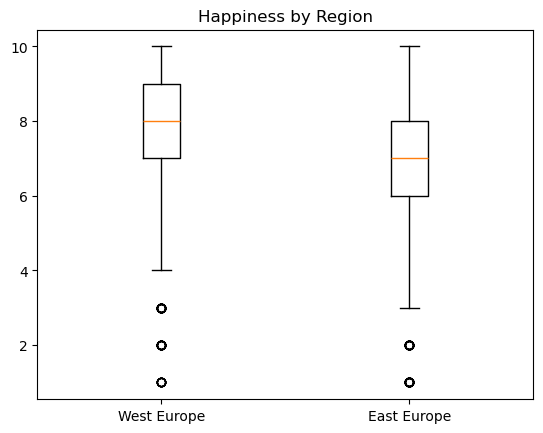

In [7]:
plt.boxplot([df_west["How happy are you?"], df_east["How happy are you?"]], labels=["West Europe", "East Europe"])
plt.title("Happiness by Region")
plt.show()

Histogramm

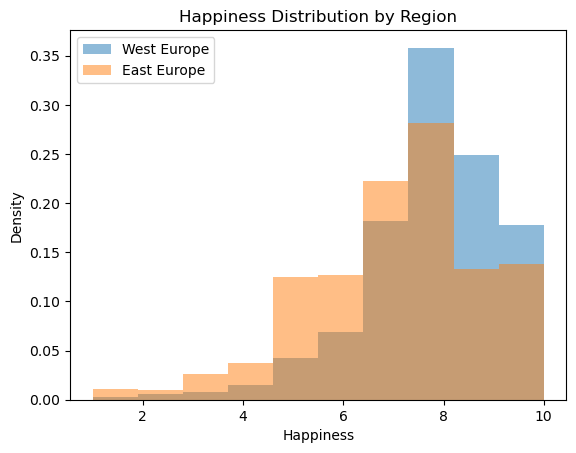

In [8]:
plt.hist(df_west["How happy are you?"], alpha=0.5, label="West Europe", density=True)
plt.hist(df_east["How happy are you?"], alpha=0.5, label="East Europe", density=True)
plt.legend()
plt.title("Happiness Distribution by Region")
plt.xlabel("Happiness")
plt.ylabel("Density")
plt.show()

## Model Training

In [11]:
import importlib
from XGBoost import xgboost_machine_learning
importlib.reload(xgboost_machine_learning)

<module 'XGBoost.xgboost_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\XGBoost\\xgboost_machine_learning.py'>

Model settings

In [12]:
my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# Model-specific hyperparameters (baseline defaults)
my_n_estimators = 100
my_max_depth = None

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

In [13]:
region_groups = {
    "west": df_west,
    "east": df_east
}

In [14]:
for name, data in region_groups.items():
    print(f"Running model for {name}...")
    my_target_column = 'How happy are you?'
    print("Shape before: ", data.shape)

    # Drop 'How satisfied with...' columns
    # They have too much predictive value and there are similar questions
    # e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
    columns_to_remove = [
        'How satisfied with present standard of living?',
        'How satisfied with family life?',
        'How satisfied with social life?',
        'How satisfied with health?',
        'How satisfied with economic situation in the country?',
        'How satisfied with accommodation?',
        'How satisfied with education?'
    ]
    data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
    print("Shape after: ", data.shape)

    model_1B, shap_results_1B = xgboost_machine_learning.run_xgb_gridsearch_and_shap(
        df=data,
        target_column=my_target_column,
        test_size=my_test_size,
        random_state=my_random_state,
        cv_folds=3,
        shap_rows=my_number_of_shaply_rows,
        number_header_rows=my_number_header_rows
    )

    shap_results_1B.to_csv(f"Results/country_{name}_shap_results_1B_optimized.csv", index=False)

Running model for west...
Shape before:  (3273, 168)
Shape after:  (3273, 161)
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
 Test RMSE: 1.3217
 Test R²: 0.2533
Starting SHAP for 5000 rows...


100%|██████████| 655/655 [00:12<00:00, 50.64it/s]



Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.175258  -0.000022
115  I generally feel that what I do in life is wor...  0.169053   0.007917
59                        Quality of education system?  0.123615  -0.002987
116     I feel I am free to decide how to live my life  0.117939  -0.015592
114                   I am optimistic about the future  0.096981   0.003435
..                                                 ...       ...        ...
142                                     Country_Kosovo  0.000000   0.000000
138                                    Country_Hungary  0.000000   0.000000
144                                  Country_Lithuania  0.000000   0.000000
148                                 Country_Montenegro  0.000000   0.000000
145                                 Country_Luxembourg  0.000000   0.000000

[150 rows x 3 columns]
Running model for east...
Shape before:  (26

100%|██████████| 527/527 [00:10<00:00, 50.20it/s]


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.200930  -0.000132
114                   I am optimistic about the future  0.198937  -0.005288
99                        Personal financial situation  0.147889   0.017047
115  I generally feel that what I do in life is wor...  0.120602   0.008265
58                         Quality of health services?  0.107660   0.004308
..                                                 ...       ...        ...
141                                      Country_Italy  0.000000   0.000000
140                                    Country_Ireland  0.000000   0.000000
139                                    Country_Iceland  0.000000   0.000000
136                                    Country_Germany  0.000000   0.000000
137                                     Country_Greece  0.000000   0.000000

[150 rows x 3 columns]


### Plot Results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

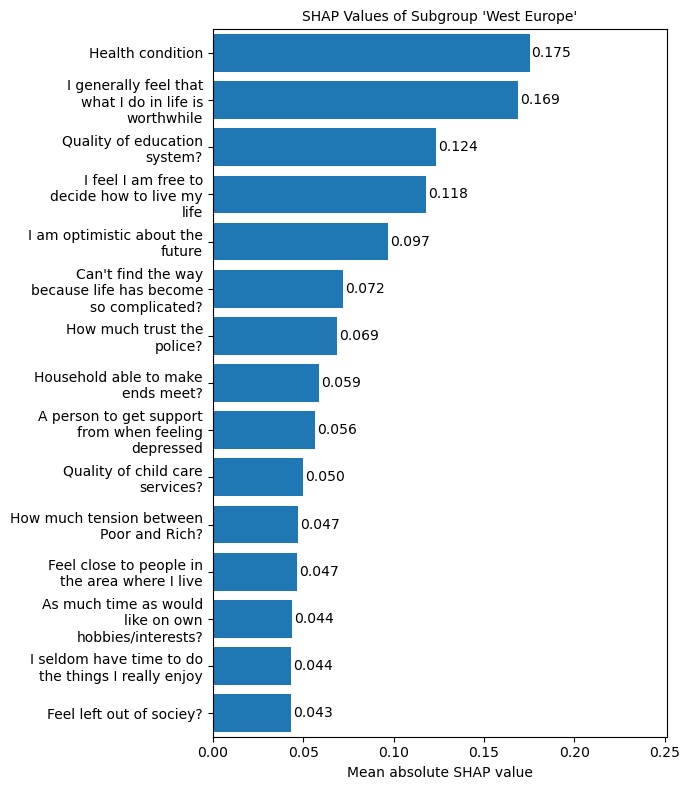

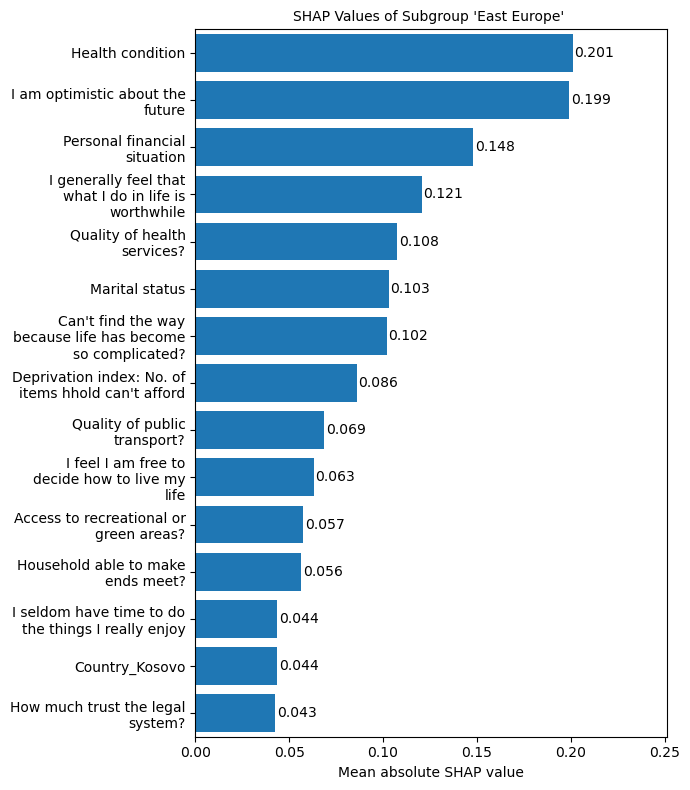

In [2]:
# Load Data
df_west = pd.read_csv("Results/country_west_shap_results_1B_optimized.csv")
df_east = pd.read_csv("Results/country_east_shap_results_1B_optimized.csv")

def plot_shap_large(df, title, max_questions=None):

    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    #plt.figure(figsize=(5.5, n * 0.6))
    plt.figure(figsize=(7, 8))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_west["Value"].max(),
        df_east["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_west, "SHAP Values of Subgroup 'West Europe'", max_questions=15)
plot_shap_large(df_east, "SHAP Values of Subgroup 'East Europe' ", max_questions=15)
plt.show()